In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
#generate cat and dog images
np.random.seed(42)

IMG_SIZE = 32

cats = []
dogs = []

# Generate Cat Images
for _ in range(1000):

    img = np.random.normal(
        loc=80,
        scale=25,
        size=(IMG_SIZE, IMG_SIZE)
    )

    img = np.clip(img, 0, 255)

    cats.append(img)

# Generate Dog Images
for _ in range(1000):

    img = np.random.normal(
        loc=180,
        scale=25,
        size=(IMG_SIZE, IMG_SIZE)
    )

    img = np.clip(img, 0, 255)

    dogs.append(img)

print("Cat Images:", len(cats))
print("Dog Images:", len(dogs))

Cat Images: 1000
Dog Images: 1000


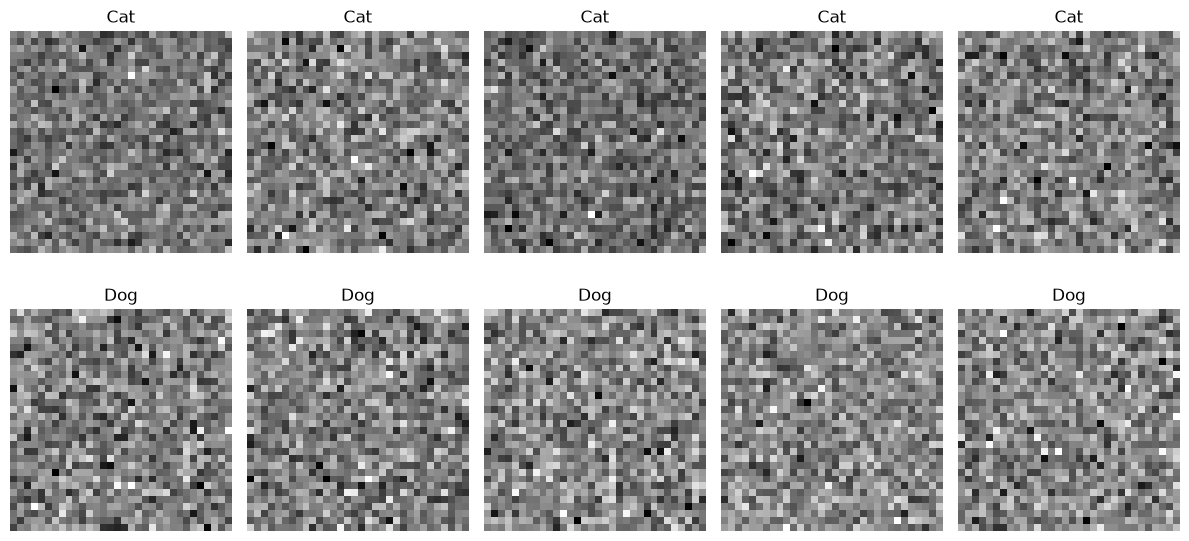

In [3]:
#visualize dataset 
plt.figure(figsize=(12,6))

for i in range(5):

    plt.subplot(2,5,i+1)

    plt.imshow(cats[i], cmap='gray')

    plt.title("Cat")

    plt.axis('off')

for i in range(5):

    plt.subplot(2,5,i+6)

    plt.imshow(dogs[i], cmap='gray')

    plt.title("Dog")

    plt.axis('off')

plt.tight_layout()

plt.show()

In [4]:
#create feature matrix
X = []
y = []

# Cats -> Label 0
for img in cats:

    X.append(img.flatten())

    y.append(0)

# Dogs -> Label 1
for img in dogs:

    X.append(img.flatten())

    y.append(1)

X = np.array(X)

y = np.array(y)

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (2000, 1024)
Labels Shape: (2000,)


In [5]:
#dataset information
print("Total Samples:", len(X))
print("Number of Features:", X.shape[1])

pd.Series(y).value_counts()

Total Samples: 2000
Number of Features: 1024


0    1000
1    1000
Name: count, dtype: int64

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1600
Testing Samples: 400


In [7]:
#train svm model
svm = SVC(

    kernel='rbf',

    gamma='scale'
)

svm.fit(

    X_train,

    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [8]:
#predictions
y_pred = svm.predict(X_test)

In [9]:
#accuracy score
accuracy = accuracy_score(

    y_test,

    y_pred
)

print(

    f"Accuracy: {accuracy*100:.2f}%"
)

Accuracy: 100.00%


In [10]:
#classification report
print(

    classification_report(

        y_test,

        y_pred,

        target_names=[

            "Cat",

            "Dog"
        ]
    )
)

              precision    recall  f1-score   support

         Cat       1.00      1.00      1.00       200
         Dog       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



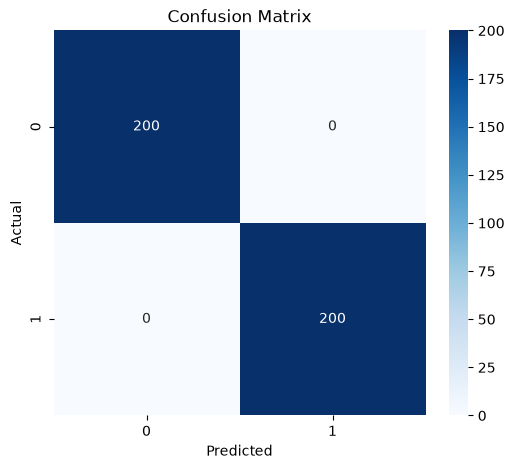

In [11]:
#confusion matrix
cm = confusion_matrix(

    y_test,

    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(

    "Confusion Matrix"
)

plt.xlabel(

    "Predicted"
)

plt.ylabel(

    "Actual"
)

plt.show()

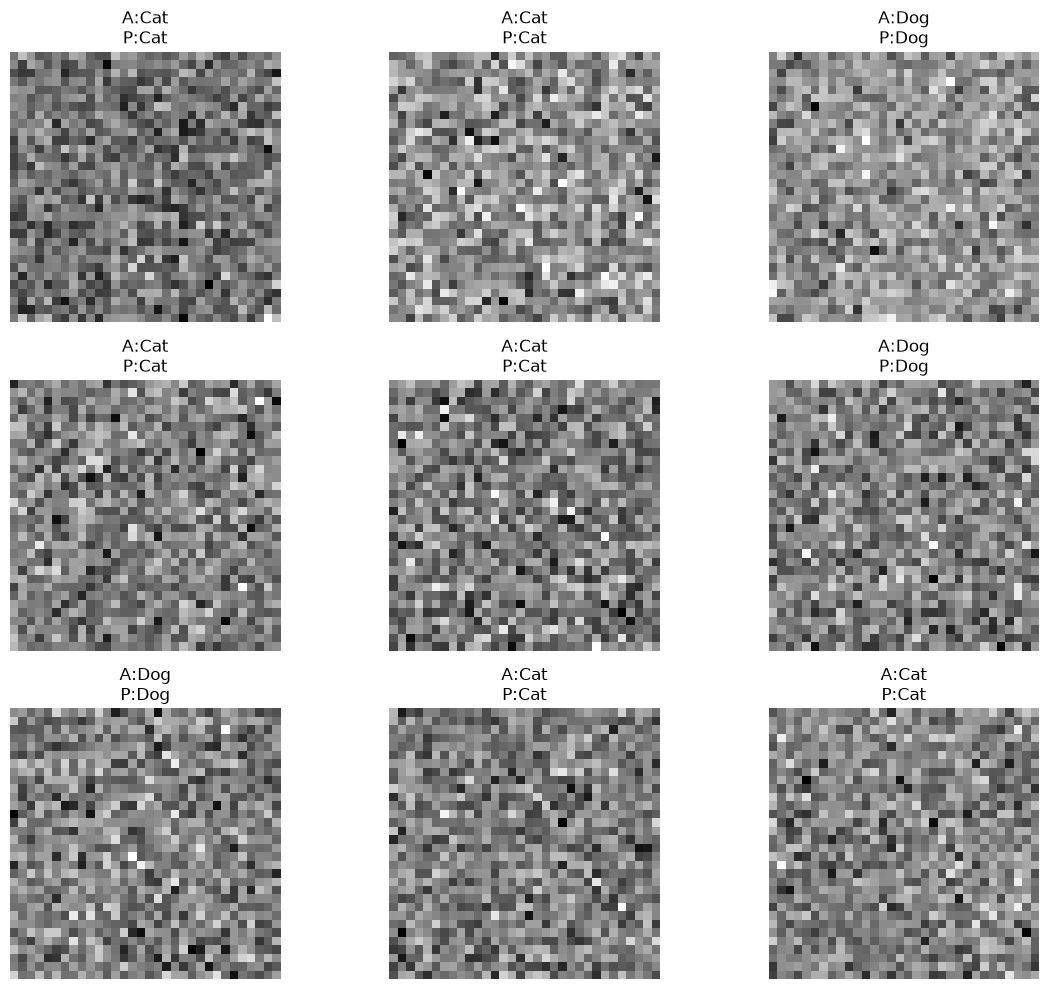

In [12]:
#actual vs predicted samples
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    image = X_test[i].reshape(

        IMG_SIZE,

        IMG_SIZE
    )

    actual = "Dog" if y_test[i] == 1 else "Cat"

    predicted = "Dog" if y_pred[i] == 1 else "Cat"

    plt.imshow(

        image,

        cmap='gray'
    )

    plt.title(

        f"A:{actual}\nP:{predicted}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [13]:
#predict new image 
sample = np.random.normal(

    loc=170,

    scale=25,

    size=(IMG_SIZE, IMG_SIZE)
)

sample = sample.flatten()

prediction = svm.predict(

    [sample]
)

if prediction[0] == 0:

    print("Predicted Class: Cat")

else:

    print("Predicted Class: Dog")

Predicted Class: Dog
